# **Spatial Maps for Mornington Peninsula**

**Types of Spatial Maps:**
 - Rainfall
 - Tmax
 - Tmin
 - Heatwave
 - Drought

**Spatial Map Output:**
 - Rainfall: mornington_rainfall_trend_map.png
 - Tmax: mornington_tmax_trend_maps.png
 - Tmin: mornington_tmin_trend_maps.png
 - Heatwaves: mornington_heatwave_trend_maps.png
 - Droughts:mornington_drought_trend_maps.png

In [2]:
# Setup, Imports, Load Gridded Data (Run Once)

import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import pymannkendall as mk

try: 
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAVE_CARTOPY = True
except ImportError:
    HAVE_CARTOPY = False

base_path = '/g/data/zv2/agcd/v1-0-4'
lat_min, lat_max = -38.50, -38.05
lon_min, lon_max = 144.68, 145.35

CACHE_DIR = '/scratch/ob22/ft3359/mornington_cache'

def load_box(var_subpath, var_name):
    def _preprocess(ds):
        return ds[[var_name]].sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

    ds = xr.open_mfdataset(
        f'{base_path}/{var_subpath}/*.nc',
        combine='by_coords',
        preprocess=_preprocess,
        chunks={'time': 365},
    )
    da = ds[var_name]
    return da.load()

precip_grid = load_box('precip/total/r005/01day', 'precip')
tmax_grid = load_box('tmax/mean/r005/01day', 'tmax')
tmin_grid = load_box('tmin/mean/r005/01day', 'tmin')

print(f"Grid Shape: lat={precip_grid.lat.size}, lon={precip_grid.lon.size}, "
      f"time={precip_grid.time.size}")

# Build Ocean Mask
def build_land_mask_from_data(daily_grid, valid_fraction_threshold=0.5):
    valid_fraction = daily_grid.notnull().mean(dim='time')
    return valid_fraction >= valid_fraction_threshold

LAND_MASK = build_land_mask_from_data(precip_grid)

print(f"Land Mask: {int(LAND_MASK.sum())} of {LAND_MASK.size} gridcells classified as land")

precip_grid = precip_grid.where(LAND_MASK)
tmax_grid = tmax_grid.where(LAND_MASK)
tmin_grid = tmin_grid.where(LAND_MASK)

valid_frac = precip_grid.notnull().mean(dim='time')
print(valid_frac.values)

os.makedirs(CACHE_DIR, exist_ok=True)

precip_grid.to_netcdf(f'{CACHE_DIR}/precip_gird_masked.nc')
tmax_grid.to_netcdf(f'{CACHE_DIR}/tmax_grid_masked.nc')
tmin_grid.to_netcdf(f'{CACHE_DIR}/tmin_grid_masked.nc')
LAND_MASK.to_netcdf(f'{CACHE_DIR}/land_mask.nc')

print(f"Saved cached grids to {CACHE_DIR}")

Grid Shape: lat=10, lon=14, time=46021
Land Mask: 140 of 140 gridcells classified as land
[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]
Saved cached grids to /scratch/ob22/ft3359/mornington_cache


In [2]:
# Setup, Imports, Load Cached Gridded Data (Fast)

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import pymannkendall as mk

try: 
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAVE_CARTOPY = True
except ImportError:
    HAVE_CARTOPY = False

lat_min, lat_max = -38.50, -38.05
lon_min, lon_max = 144.68, 145.35

CACHE_DIR = '/scratch/ob22/ft3359/mornington_cache'

precip_grid = xr.open_dataarray(f'{CACHE_DIR}/precip_gird_masked.nc').load()
tmax_grid = xr.open_dataarray(f'{CACHE_DIR}/tmax_grid_masked.nc').load()
tmin_grid = xr.open_dataarray(f'{CACHE_DIR}/tmin_grid_masked.nc').load()
LAND_MASK = xr.open_dataarray(f'{CACHE_DIR}/land_mask.nc').load()

print(f"Loaded cached grids: lat={precip_grid.lat.size}, lon={precip_grid.lon.size}",
      f"time={precip_grid.time.size}")

/g/data/xp65/admin/analysis3/sitecustomize.py:72: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  mod = _real_import(name, globals, locals, fromlist, level)


Loaded cached grids: lat=10, lon=14 time=46021


In [10]:
# Shared Helper Functions (trend test + Plotting)

def gridded_mk_trend(annual_da, min_years=10):
    """Apply MK/Sen's slope trend test at every grid cell.
    annual_da must have dims (time, lat, lon), loaded into memory."""
    def _mk_pixel(values_1d):
        mask = ~np.isnan(values_1d)
        if mask.sum() < min_years:
            return np.nan, np.nan, np.nan
        try:
            result = mk.original_test(values_1d[mask])
        except Exception:
            return np.nan, np.nan, np.nan
        return result.slope * 10, result.p, result.z  # slope -> per decade

    slope, pval, zval = xr.apply_ufunc(
        _mk_pixel, annual_da,
        input_core_dims=[['time']],
        output_core_dims=[[], [], []],
        vectorize=True,
        output_dtypes=[float, float, float],
    )
    return xr.Dataset({'sen_slope_per_decade': slope, 'p_value': pval, 'z': zval})

def plot_trend_map(trend_ds, title, cbar_label, cmap='RdBu_r', ax=None, symmetric=True, vmin=None, vmax=None):
    slope = trend_ds['sen_slope_per_decade']
    pval = trend_ds['p_value']
    fig = ax.figure
    if vmin is None or vmax is None:
        if symmetric:
            vmax = np.nanmax(np.abs(slope.values))
            vmin = -vmax
        else:
            vmin, vmax = np.nanmin(slope.values), np.nanmax(slope.values)
    if HAVE_CARTOPY:
        mesh = ax.pcolormesh(slope.lon, slope.lat, slope, cmap=cmap, vmin=vmin, vmax=vmax,
                              transform=ccrs.PlateCarree(), shading='auto')
        ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.8)
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
        gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
        gl.top_labels = False
        gl.right_labels = False
    else:
        mesh = ax.pcolormesh(slope.lon, slope.lat, slope, cmap=cmap, vmin=vmin, vmax=vmax, shading='auto')
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
    sig_mask = pval.values < 0.05
    lon2d, lat2d = np.meshgrid(slope.lon.values, slope.lat.values)
    scatter_kwargs = dict(s=8, color='black', marker='.')
    if HAVE_CARTOPY:
        ax.scatter(lon2d[sig_mask], lat2d[sig_mask], transform=ccrs.PlateCarree(), **scatter_kwargs)
    else:
        ax.scatter(lon2d[sig_mask], lat2d[sig_mask], **scatter_kwargs)
    cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', shrink=0.7, extend='both')
    cbar.set_label(cbar_label)
    ax.set_title(title)
    return cbar

def make_subplot_fig(nrows, ncols, figsize):
    subplot_kw = {'projection': ccrs.PlateCarree()} if HAVE_CARTOPY else {}
    return plt.subplots(nrows, ncols, figsize=figsize, subplot_kw=subplot_kw)

Saved: mornington_rainfall_trend_map.png


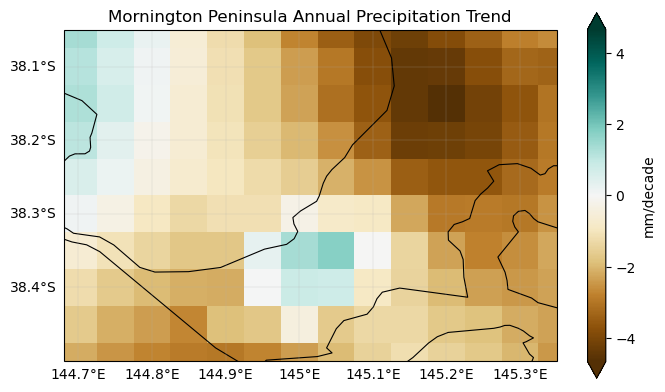

In [30]:
# Rainfall Trend Map (mm/decade)

precip_annual_grid = precip_grid.resample(time='YS').sum(skipna=True)
precip_trend_grid = gridded_mk_trend(precip_annual_grid)

fig, ax = make_subplot_fig(1, 1, figsize=(7, 6))
plot_trend_map(precip_trend_grid, 'Mornington Peninsula Annual Precipitation Trend', 'mm/decade', cmap='BrBG', ax=ax)

fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig('mornington_rainfall_trend_map.png', dpi=200)
print("Saved: mornington_rainfall_trend_map.png")

Saved: mornington_tmax_trend_maps.png


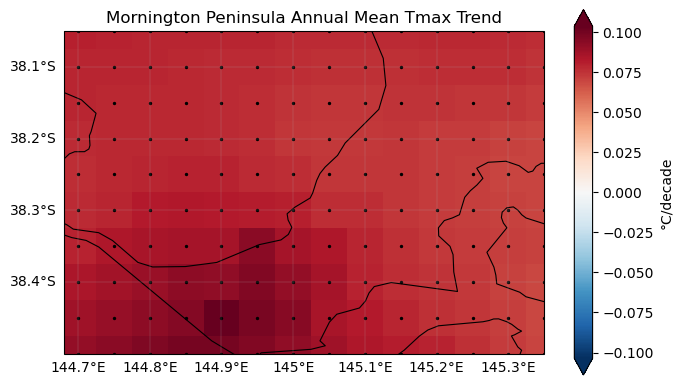

In [10]:
# Tmax Trend Map (annual mean Tmax)
tmax_annual_mean_grid = tmax_grid.resample(time='YS').mean(skipna=True)
tmax_trend_grid = gridded_mk_trend(tmax_annual_mean_grid)

fig, ax = make_subplot_fig(1, 1, figsize=(7, 6))
plot_trend_map(tmax_trend_grid, 'Mornington Peninsula Annual Mean Tmax Trend', '°C/decade', cmap='RdBu_r', ax=ax)

fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig('mornington_tmax_trend_maps.png', dpi=200)
print("Saved: mornington_tmax_trend_maps.png")

Saved: mornington_tmin_trend_maps.png


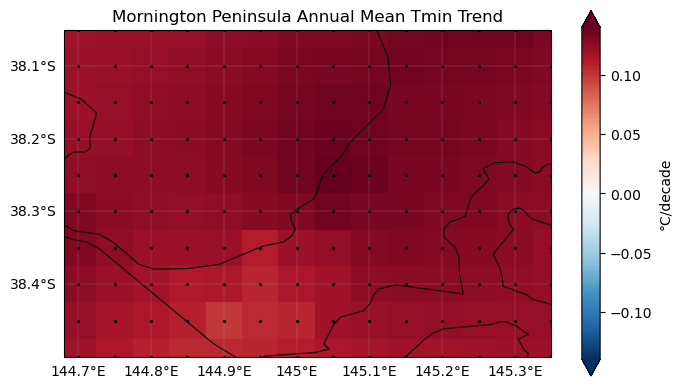

In [11]:
# Tmin Trend Map (annual mean Tmin)
tmin_annual_mean_grid = tmin_grid.resample(time='YS').mean(skipna=True)
tmin_trend_grid = gridded_mk_trend(tmin_annual_mean_grid)

fig, ax = make_subplot_fig(1, 1, figsize=(7, 6))
plot_trend_map(tmin_trend_grid, 'Mornington Peninsula Annual Mean Tmin Trend', '°C/decade', cmap='RdBu_r', ax=ax)

fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig('mornington_tmin_trend_maps.png', dpi=200)
print("Saved: mornington_tmin_trend_maps.png")

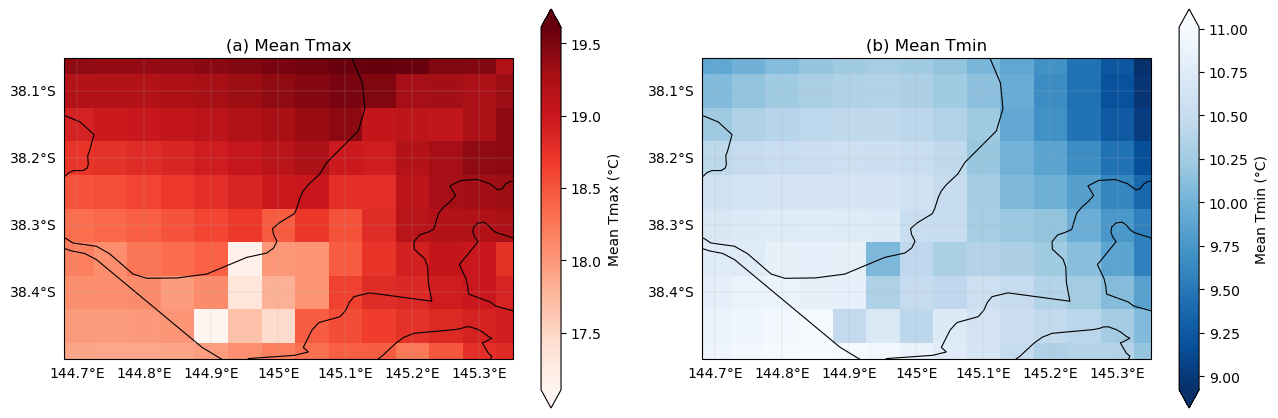

In [15]:
# Mean Tmax / Tmin Spatial Maps
def plot_mean_map(mean_da, title, cbar_label, cmap='inferno', ax=None):
    fig = ax.figure
    vmin, vmax = np.nanmin(mean_da.values), np.nanmax(mean_da.values)
    if HAVE_CARTOPY:
        mesh = ax.pcolormesh(mean_da.lon, mean_da.lat, mean_da, cmap=cmap, vmin=vmin, vmax=vmax,
                             transform=ccrs.PlateCarree(), shading='auto')
        ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.8)
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
        gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
        gl.top_labels = False
        gl.right_labels = False
    else:
        mesh = ax.pcolormesh(mean_da.lon, mean_da.lat, mean_da, cmap=cmap, vmin=vmin, vmax=vmax, shading='auto')
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
    cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', shrink=0.7, extend='both')
    cbar.set_label(cbar_label)
    ax.set_title(title)

tmax_mean = tmax_grid.mean(dim='time', skipna=True)
tmin_mean = tmin_grid.mean(dim='time', skipna=True)

fig, axes = make_subplot_fig(1, 2, figsize=(13, 6))
plot_mean_map(tmax_mean, '(a) Mean Tmax', 'Mean Tmax (°C)', cmap='Reds', ax=axes[0])
plot_mean_map(tmin_mean, '(b) Mean Tmin', 'Mean Tmin (°C)', cmap='Blues_r', ax=axes[1])
plt.tight_layout()
fig.savefig('mornington_tmax_tmin_maps.png', dpi=200)
plt.show()

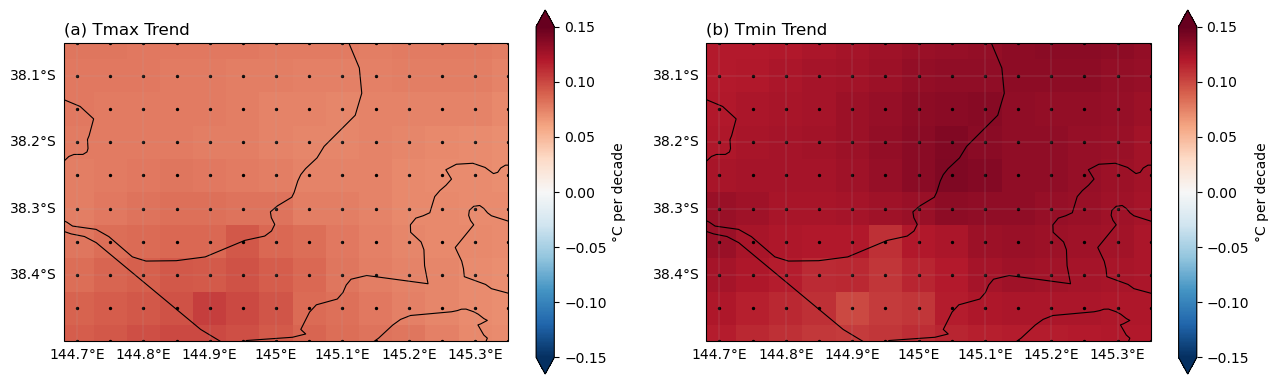

In [14]:
# Mean Tmax & Tmin change over time spatial plot

tmax_annual = tmax_grid.resample(time='1YE').mean(skipna=True)
tmin_annual = tmin_grid.resample(time='1YE').mean(skipna=True)
tmax_trend = gridded_mk_trend(tmax_annual)
tmin_trend = gridded_mk_trend(tmin_annual)
if LAND_MASK is not None:
    tmax_trend = tmax_trend.where(LAND_MASK)
    tmin_trend = tmin_trend.where(LAND_MASK)

raw_max = np.nanmax([
    np.nanmax(np.abs(tmax_trend['sen_slope_per_decade'].values)),
    np.nanmax(np.abs(tmin_trend['sen_slope_per_decade'].values)),
])
step = 0.05
shared_vmax = np.ceil(raw_max / step) * step
shared_vmin = -shared_vmax

fig, axes = make_subplot_fig(1, 2, figsize=(13, 5.5))
cbar1 = plot_trend_map(tmax_trend, '(a) Tmax Trend', '°C per decade', cmap='RdBu_r', ax=axes[0],
                        vmin=shared_vmin, vmax=shared_vmax)
cbar2 = plot_trend_map(tmin_trend, '(b) Tmin Trend', '°C per decade', cmap='RdBu_r', ax=axes[1],
                        vmin=shared_vmin, vmax=shared_vmax)

shared_ticks = np.arange(shared_vmin, shared_vmax + step/2, step)
cbar1.set_ticks(shared_ticks)
cbar2.set_ticks(shared_ticks)

for ax in axes:
    ax.title.set_ha('left')
    ax.title.set_x(0)
fig.tight_layout()
fig.savefig('mornington_tmax_tmin_change_maps.png', dpi=200)
plt.show()

In [13]:
# Raw Occurrance & Spilt-period difference

def gridded_total_occurrence(daily_grid, threshold):
    # Total number of days exceeding threshold across the full record
    exceed = (daily_grid > threshold).astype(float)
    return exceed.sum(dim='time', skipna=True)

def gridded_period_difference(daily_grid, threshold, early_years, recent_years):
    # Mean Annual Exceedance days: recent period minus early period
    exceed = (daily_grid > threshold).astype(float)
    annual_counts = exceed.resample(time='YS').sum(skipna=True)
    early = annual_counts.sel(time=slice(f'{early_years[0]}-01-01', f'{early_years[1]}-12-31')).mean(dim='time')
    recent = annual_counts.sel(time=slice(f'{recent_years[0]}-01-01', f'{recent_years[1]}-12-31')).mean(dim='time')
    return recent - early

def gridded_period_percent_difference(daily_grid, threshold, early_years, recent_years, min_early_days=0.1):
    # Percentage change in mean annual exceedance days, recent vs early period
    exceed = (daily_grid > threshold).astype(float)
    annual_counts = exceed.resample(time='YS').sum(skipna=True)
    early = annual_counts.sel(time=slice(f'{early_years[0]}-01-01', f'{early_years[1]}-12-31')).mean(dim='time')
    recent = annual_counts.sel(time=slice(f'{recent_years[0]}-01-01', f'{recent_years[1]}-12-31')).mean(dim='time')
    pct_change = 100 * (recent - early) / early
    pct_change = pct_change.where(early >= min_early_days)
    return pct_change

Saved: mornington_tmax_extreme_change_percent.png


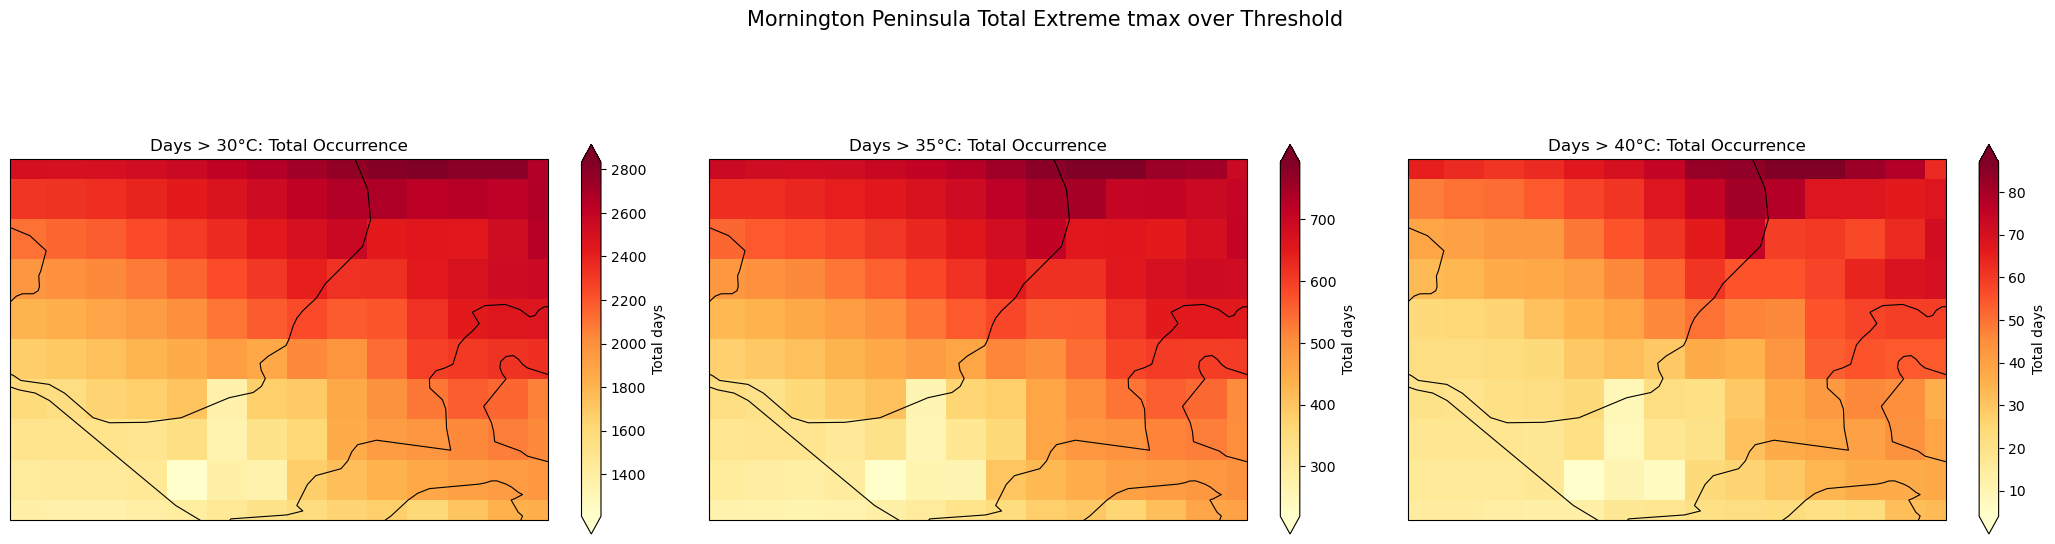

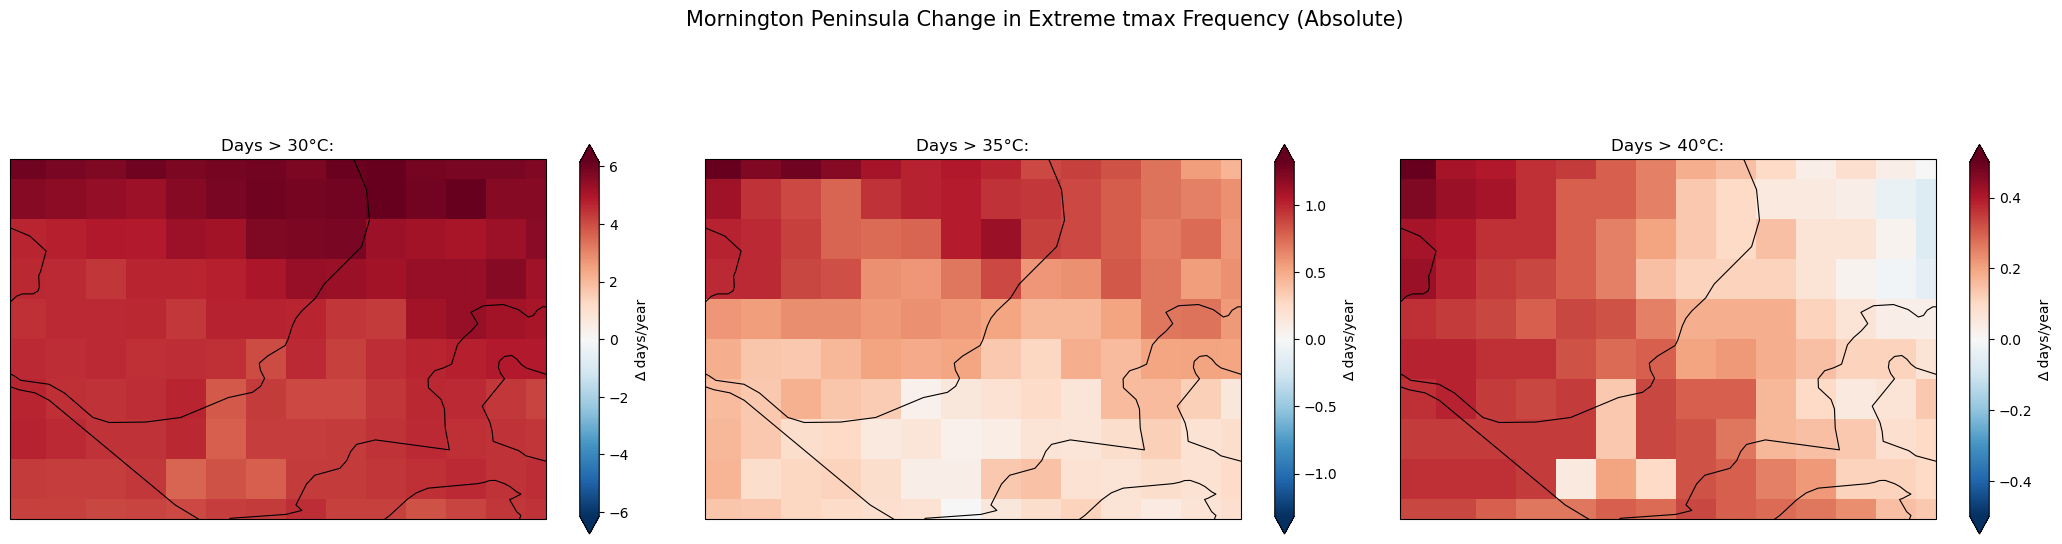

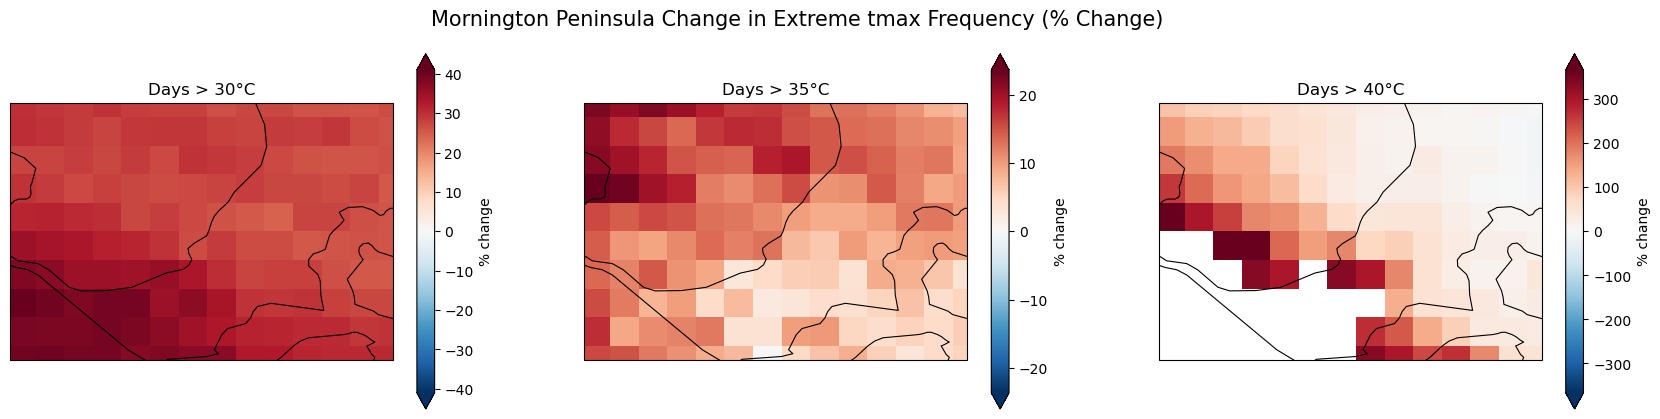

In [41]:
# Plot Raw Occurrance Map

fig, axes = make_subplot_fig(1, 3, figsize=(21, 6))
for ax, threshold in zip(np.atleast_1d(axes), [30, 35, 40]):
    total = gridded_total_occurrence(tmax_grid, threshold)
    mesh = ax.pcolormesh(total.lon, total.lat, total, cmap='YlOrRd', shading='auto', transform=ccrs.PlateCarree() if HAVE_CARTOPY else None)

    if HAVE_CARTOPY:
        ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.8)
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    fig.colorbar(mesh, ax=ax, shrink=0.8, label='Total days', extend='both')
    ax.set_title(f'Days > {threshold}°C: Total Occurrence')

fig.suptitle('Mornington Peninsula Total Extreme tmax over Threshold', fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.92])

# Plot Split-period Difference Map

fig, axes = make_subplot_fig(1, 3, figsize=(21, 6))
for ax, threshold in zip(np.atleast_1d(axes), [30, 35, 40]):
    diff = gridded_period_difference(tmax_grid, threshold, (1910, 1969), (1996, 2025))
    vmax = np.nanmax(np.abs(diff.values))
    mesh = ax.pcolormesh(diff.lon, diff.lat, diff, cmap='RdBu_r', vmin=-vmax, vmax=vmax, shading='auto', transform=ccrs.PlateCarree() if HAVE_CARTOPY else None)

    if HAVE_CARTOPY:
        ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.8)
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    fig.colorbar(mesh, ax=ax, shrink=0.8, label='∆ days/year', extend='both')
    ax.set_title(f'Days > {threshold}°C:')

fig.suptitle('Mornington Peninsula Change in Extreme tmax Frequency (Absolute)', fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.92])

# Plot Split-period Difference Map (Percentage Change)

fig, axes = make_subplot_fig(1, 3, figsize=(21, 6))
for ax, threshold in zip(np.atleast_1d(axes), [30, 35, 40]):
    pct_diff = gridded_period_percent_difference(tmax_grid, threshold, (1910, 1969), (1996, 2025))
    vmax = np.nanmax(np.abs(pct_diff.values)) if np.any(~np.isnan(pct_diff.values)) else 100
    mesh = ax.pcolormesh(pct_diff.lon, pct_diff.lat, pct_diff, cmap='RdBu_r', vmin=-vmax, vmax=vmax, shading='auto', transform=ccrs.PlateCarree() if HAVE_CARTOPY else None)

    if HAVE_CARTOPY: 
        ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.8)
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    fig.colorbar(mesh, ax=ax, shrink=0.8, label='% change', extend='both')
    ax.set_title(f'Days > {threshold}°C')
fig.suptitle('Mornington Peninsula Change in Extreme tmax Frequency (% Change)', fontsize=15, y=0.85)
fig.subplots_adjust(top=0.85)
fig.savefig('mornington_tmax_extreme_change_percent.png', dpi=200)
print("Saved: mornington_tmax_extreme_change_percent.png")

In [22]:
# Tmin Maps 
def gridded_total_occurrence_tmin(daily_grid, threshold):
    # Total number of days exceeding threshold across the full record
    exceed = (daily_grid > threshold).astype(float)
    return exceed.sum(dim='time', skipna=True)

def gridded_period_difference_tmin(daily_grid, threshold, early_years, recent_years):
    # Mean Annual Exceedance days: recent period minus early period
    exceed = (daily_grid > threshold).astype(float)
    annual_counts = exceed.resample(time='YS').sum(skipna=True)
    early = annual_counts.sel(time=slice(f'{early_years[0]}-01-01', f'{early_years[1]}-12-31')).mean(dim='time')
    recent = annual_counts.sel(time=slice(f'{recent_years[0]}-01-01', f'{recent_years[1]}-12-31')).mean(dim='time')
    return recent - early

def gridded_period_percent_difference_tmin(daily_grid, threshold, early_years, recent_years, min_early_days=0.1):
    # Percentage change in mean annual exceedance days, recent vs early period
    exceed = (daily_grid > threshold).astype(float)
    annual_counts = exceed.resample(time='YS').sum(skipna=True)
    early = annual_counts.sel(time=slice(f'{early_years[0]}-01-01', f'{early_years[1]}-12-31')).mean(dim='time')
    recent = annual_counts.sel(time=slice(f'{recent_years[0]}-01-01', f'{recent_years[1]}-12-31')).mean(dim='time')
    pct_change = 100 * (recent - early) / early
    pct_change = pct_change.where(early >= min_early_days)
    return pct_change

TMIN_THRESHOLDS = [20, 25]

Saved: mornington_tmin_extreme_change_percent.png


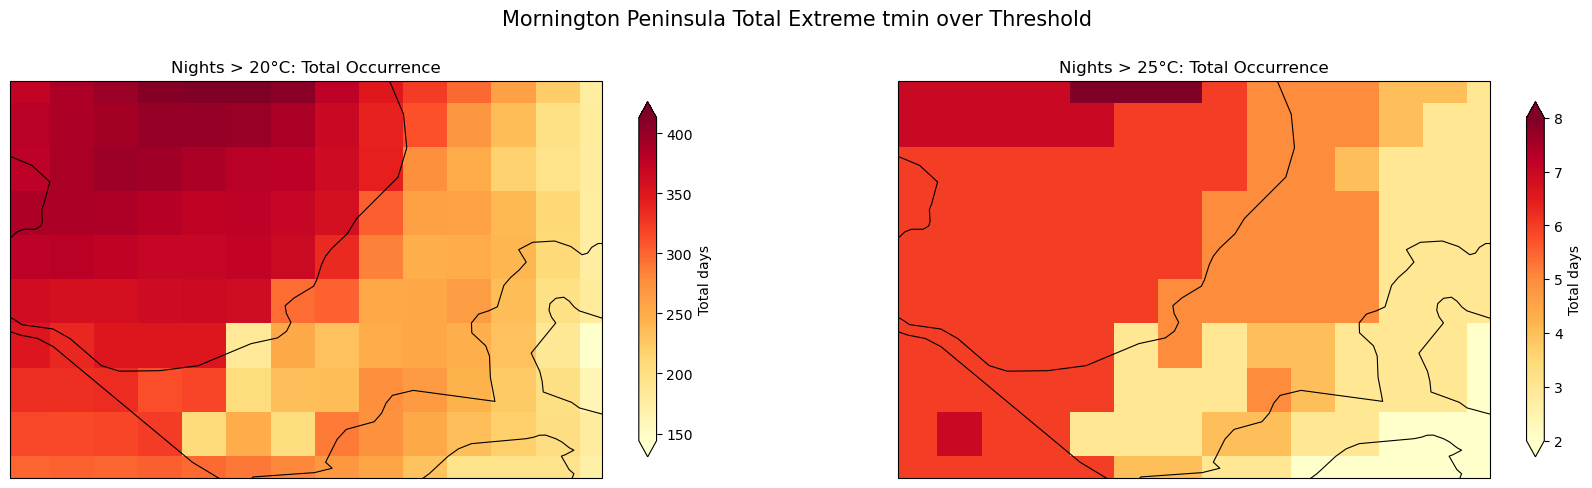

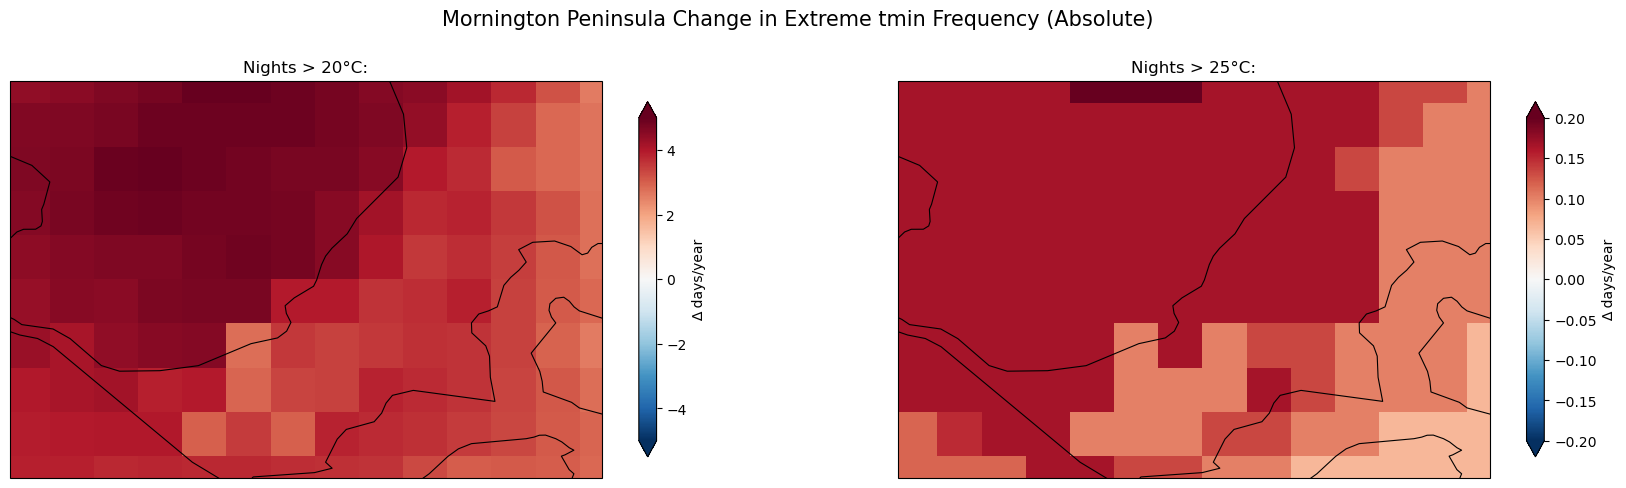

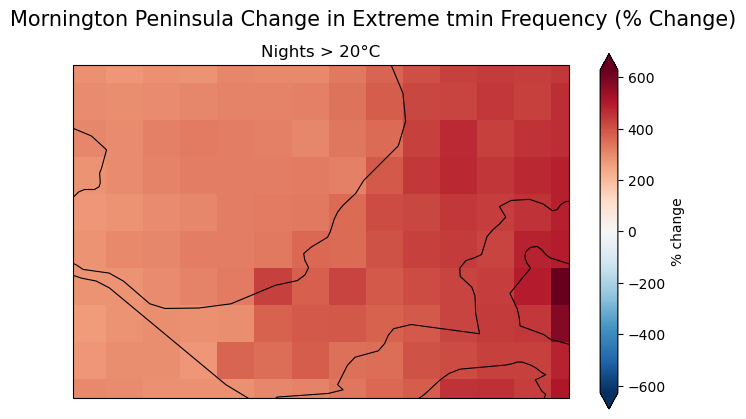

In [43]:
# Plot Raw Occurrence Map (tmin)
fig, axes = make_subplot_fig(1, 2, figsize=(21, 6))
for ax, threshold in zip(np.atleast_1d(axes), TMIN_THRESHOLDS):
    total = gridded_total_occurrence_tmin(tmin_grid, threshold)
    mesh = ax.pcolormesh(total.lon, total.lat, total, cmap='YlOrRd', shading='auto', transform=ccrs.PlateCarree() if HAVE_CARTOPY else None)
    if HAVE_CARTOPY:
        ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.8)
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    fig.colorbar(mesh, ax=ax, shrink=0.8, label='Total days', extend='both')
    ax.set_title(f'Nights > {threshold}°C: Total Occurrence')
fig.suptitle('Mornington Peninsula Total Extreme tmin over Threshold', fontsize=15, y=0.93)
fig.subplots_adjust(top=0.85)


# Plot Split-period Difference Map (tmin, absolute)
fig, axes = make_subplot_fig(1, 2, figsize=(21, 6))
for ax, threshold in zip(np.atleast_1d(axes), TMIN_THRESHOLDS):
    diff = gridded_period_difference_tmin(tmin_grid, threshold, (1910, 1969), (1996, 2025))
    vmax = np.nanmax(np.abs(diff.values))
    mesh = ax.pcolormesh(diff.lon, diff.lat, diff, cmap='RdBu_r', vmin=-vmax, vmax=vmax, shading='auto', transform=ccrs.PlateCarree() if HAVE_CARTOPY else None)
    if HAVE_CARTOPY:
        ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.8)
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    fig.colorbar(mesh, ax=ax, shrink=0.8, label='∆ days/year', extend='both')
    ax.set_title(f'Nights > {threshold}°C:')
fig.suptitle('Mornington Peninsula Change in Extreme tmin Frequency (Absolute)', fontsize=15, y=0.93)
fig.subplots_adjust(top=0.85)

# Plot Split-period Difference Map (tmin, % change)
fig, axes = make_subplot_fig(1, 1, figsize=(8, 6))
for ax, threshold in zip(np.atleast_1d(axes), TMIN_THRESHOLDS):
    pct_diff = gridded_period_percent_difference_tmin(tmin_grid, threshold, (1910, 1969), (1996, 2025))
    vmax = np.nanmax(np.abs(pct_diff.values)) if np.any(~np.isnan(pct_diff.values)) else 100
    mesh = ax.pcolormesh(pct_diff.lon, pct_diff.lat, pct_diff, cmap='RdBu_r', vmin=-vmax, vmax=vmax, shading='auto', transform=ccrs.PlateCarree() if HAVE_CARTOPY else None)
    if HAVE_CARTOPY:
        ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.8)
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    fig.colorbar(mesh, ax=ax, shrink=0.8, label='% change', extend='both')
    ax.set_title(f'Nights > {threshold}°C')
fig.suptitle('Mornington Peninsula Change in Extreme tmin Frequency (% Change)', fontsize=15, y=0.85)
fig.subplots_adjust(top=0.85)
fig.savefig('mornington_tmin_extreme_change_percent.png', dpi=200)
print("Saved: mornington_tmin_extreme_change_percent.png")

Running per-pixel drought trend analysis over 10x14 grid cells...
  row 1/10 done
  row 2/10 done
  row 3/10 done
  row 4/10 done
  row 5/10 done
  row 6/10 done
  row 7/10 done
  row 8/10 done
  row 9/10 done
  row 10/10 done
Saved: mornington_drought_trend_maps.png


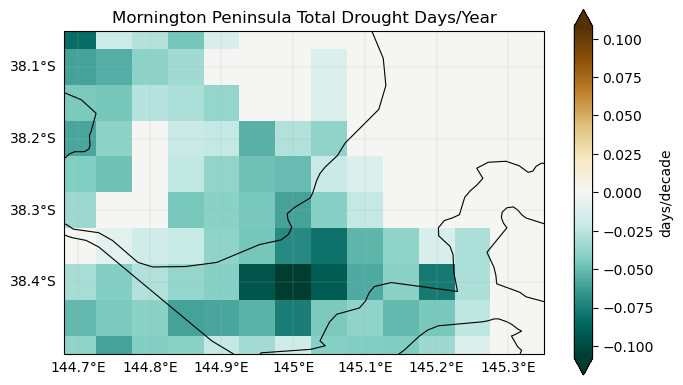

In [26]:
# Drought Trend Map
ROLL_WINDOW_DAYS = 28
MIN_EVENT_LEN_DAYS = 14
DEFICIT_THRESHOLD_PCT = 50

def mk_trend_series(series, min_n=8):
    s = series.dropna()
    if len(s) < min_n:
        return np.nan, np.nan
    try:
        result = mk.original_test(s.values)
    except Exception:
        return np.nan, np.nan
    return result.slope, result.p

def pixel_drought_trends(precip_1d, time_index):
    s = pd.Series(precip_1d, index=time_index).sort_index()
    da = xr.DataArray(s.values, dims='time', coords={'time': s.index})
    roll_sum = da.rolling(time=ROLL_WINDOW_DAYS, min_periods=ROLL_WINDOW_DAYS).sum()
    doy = roll_sum['time'].dt.dayofyear
    clim = roll_sum.groupby(doy).mean(skipna=True)
    clim_expanded = clim.sel(dayofyear=doy)
    pct_of_normal = 100 * roll_sum / clim_expanded
    df = pd.DataFrame({'time': da['time'].values, 'pct_of_normal': pct_of_normal.values})
    df = df.dropna(subset=['pct_of_normal']).reset_index(drop=True)
    if df.empty:
        return np.nan, np.nan
    df['is_deficit'] = df['pct_of_normal'] < DEFICIT_THRESHOLD_PCT
    df['run_id'] = (df['is_deficit'] != df['is_deficit'].shift()).cumsum()
    events = []
    for run_id, group in df[df['is_deficit']].groupby('run_id'):
        duration = len(group)
        if duration < MIN_EVENT_LEN_DAYS:
            continue
        events.append({'duration_days': duration, 'year': pd.Timestamp(group['time'].iloc[0]).year})
    events_df = pd.DataFrame(events)
    if events_df.empty:
        return np.nan, np.nan
    year_range = np.arange(int(df['time'].min().year), int(df['time'].max().year) + 1)
    annual = pd.DataFrame({'year': year_range})
    annual['total_drought_days'] = annual['year'].map(events_df.groupby('year')['duration_days'].sum()).fillna(0)
    d_slope, d_p = mk_trend_series(annual.set_index('year')['total_drought_days'], min_n=8)
    return d_slope, d_p

time_index = pd.to_datetime(precip_grid['time'].values)
lats, lons = precip_grid['lat'].values, precip_grid['lon'].values
n_lat, n_lon = len(lats), len(lons)

out_names = ['totaldays_slope', 'totaldays_p']
out_grids = {name: np.full((n_lat, n_lon), np.nan) for name in out_names}

print(f"Running per-pixel drought trend analysis over {n_lat}x{n_lon} grid cells...")
for i in range(n_lat):
    for j in range(n_lon):
        precip_1d = precip_grid.isel(lat=i, lon=j).values
        results = pixel_drought_trends(precip_1d, time_index)
        for name, val in zip(out_names, results):
            out_grids[name][i, j] = val
    print(f"  row {i+1}/{n_lat} done")

def make_trend_ds(slope_key, p_key):
    return xr.Dataset({
        'sen_slope_per_decade': (('lat', 'lon'), out_grids[slope_key]),
        'p_value': (('lat', 'lon'), out_grids[p_key]),
    }, coords={'lat': lats, 'lon': lons})

drought_totaldays_trend_grid = make_trend_ds('totaldays_slope', 'totaldays_p')

fig, ax = make_subplot_fig(1, 1, figsize=(7, 6))
plot_trend_map(drought_totaldays_trend_grid, 'Mornington Peninsula Total Drought Days/Year', 'days/decade', cmap='BrBG_r', ax=ax)

fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig('mornington_drought_trend_maps.png', dpi=200)
print("Saved: mornington_drought_trend_maps.png")